### 1-2. Завантаження датасету та Data Cleaning
**Завдання:** Обрати унікальний датасет, який відповідає заданим критеріям (наявність категоріальних та числових атрибутів, наявність пропусків). Здійснити Data Cleaning.

**Датасет:** Automobile Data Set (Характеристики автомобілів).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 
           'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 
           'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 
           'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

df = pd.read_csv(url, names=columns, na_values="?")

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

display(df.head())

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### 3. Графік залежності (Scatter plot)
**Завдання:** Побудувати графік залежності одного integer/real атрибута від іншого.
Подивимося, як потужність двигуна (horsepower) впливає на ціну автомобіля (price).

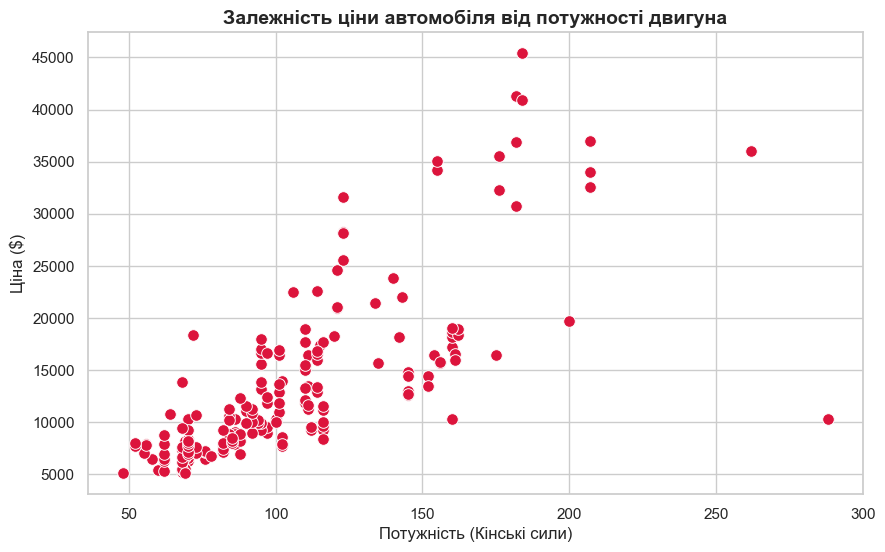

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='horsepower', y='price', color='crimson', s=70)

plt.title('Залежність ціни автомобіля від потужності двигуна', fontsize=14, fontweight='bold')
plt.xlabel('Потужність (Кінські сили)', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12) 

plt.show()

### 4. Гістограма по одному з атрибутів
**Завдання:** Побудувати гістограму, що показує кількість елементів у 5 заданих діапазонах.
Ми проаналізуємо розподіл цін на автомобілі, розбивши їх рівно на 5 цінових сегментів.

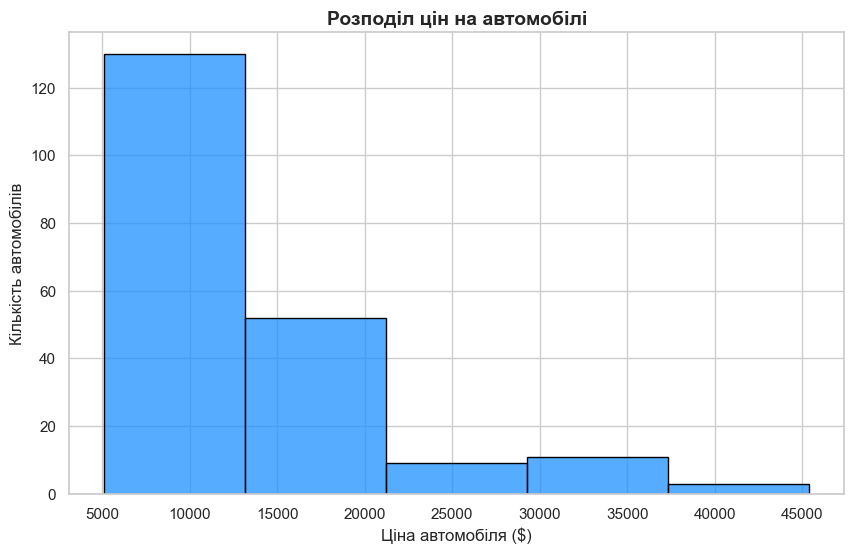

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='price', bins=5, color='dodgerblue', edgecolor='black')

plt.title('Розподіл цін на автомобілі', fontsize=14, fontweight='bold')
plt.xlabel('Ціна автомобіля ($)', fontsize=12)
plt.ylabel('Кількість автомобілів', fontsize=12)

plt.show()

### 5. Багатовимірна візуалізація
**Завдання:** Побудувати графіки, що відображають залежність декількох вимірів даних одночасно.

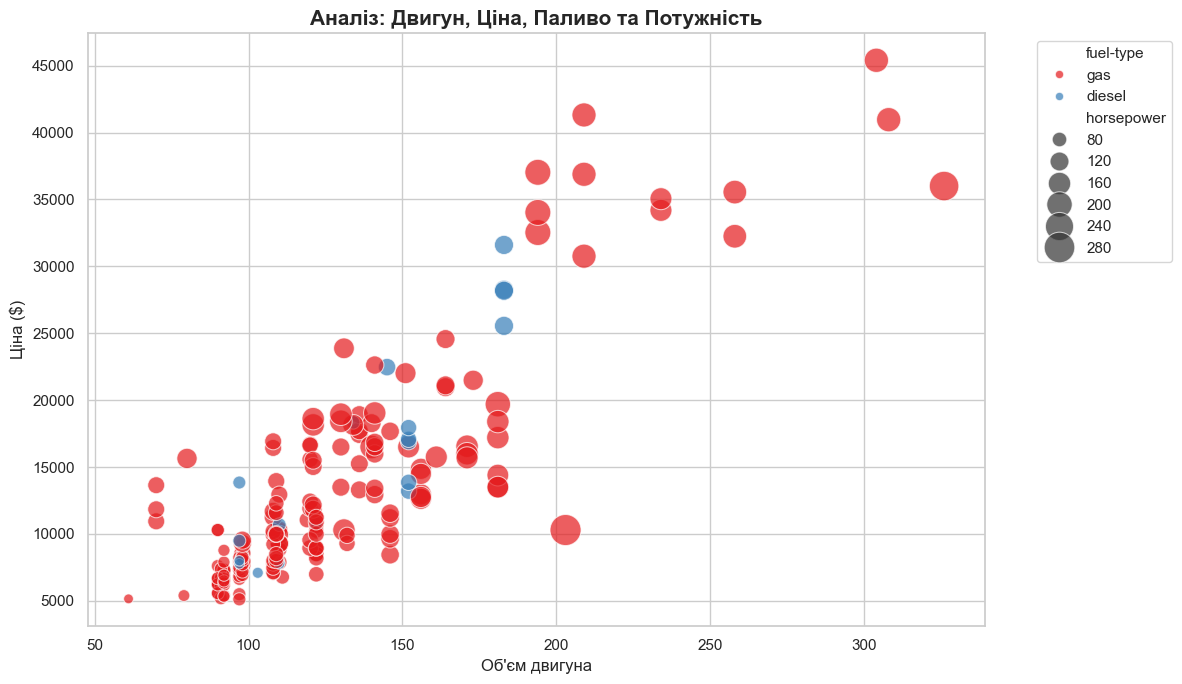

In [8]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df, 
    x='engine-size', 
    y='price', 
    hue='fuel-type',     
    size='horsepower',   
    sizes=(50, 500),     
    alpha=0.7,           
    palette='Set1'
)

plt.title('Аналіз: Двигун, Ціна, Паливо та Потужність', fontsize=15, fontweight='bold')
plt.xlabel('Об\'єм двигуна', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6. Додаткові графіки: Кореляція та розподіл за марками
**Завдання:** Побудувати графіки, що показують корисну статистичну інформацію.
1. Теплова карта кореляції (взаємозв'язок усіх числових атрибутів).
2. Стовпчаста діаграма середньої ціни за маркою авто.


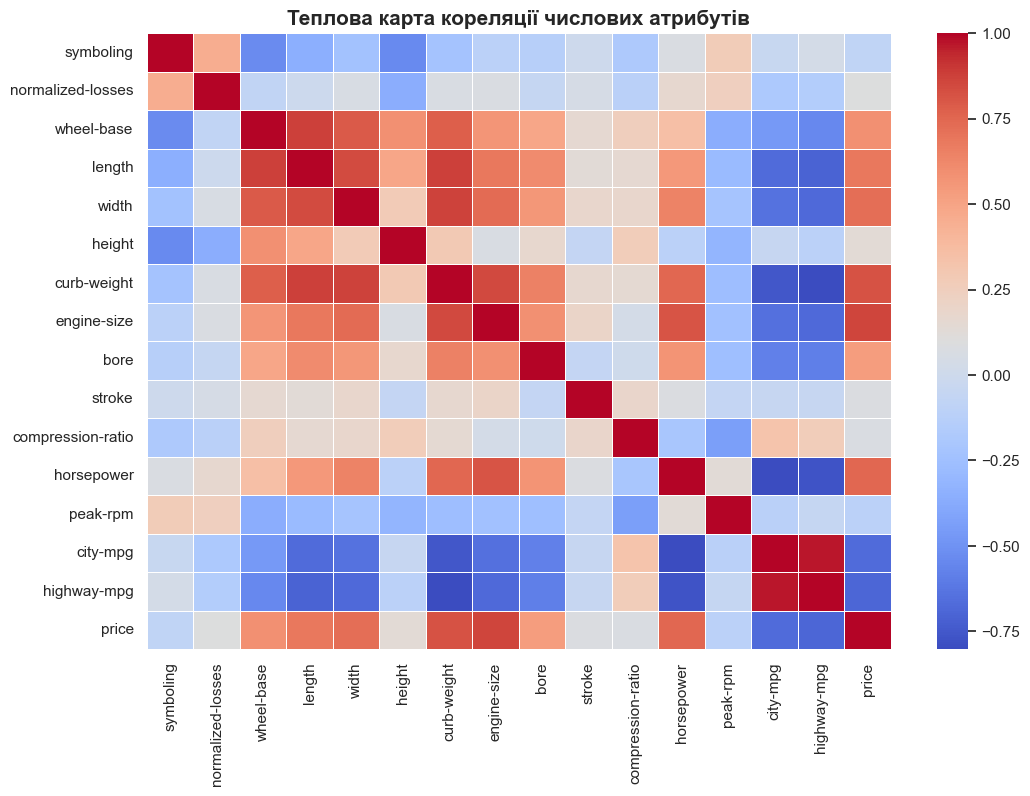

C:\Users\yandu\AppData\Local\Temp\ipykernel_24236\948035052.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_by_make, x='make', y='price', palette='viridis')


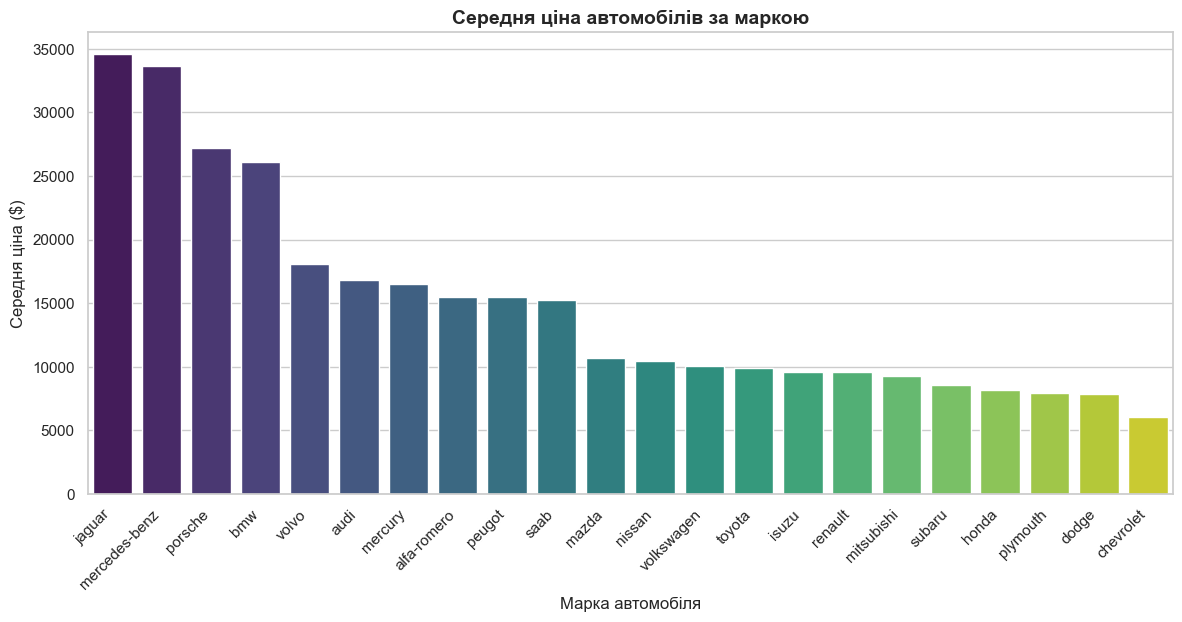

In [9]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Теплова карта кореляції числових атрибутів', fontsize=15, fontweight='bold')
plt.show()

plt.figure(figsize=(14, 6))
price_by_make = df.groupby('make')['price'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=price_by_make, x='make', y='price', palette='viridis')
plt.title('Середня ціна автомобілів за маркою', fontsize=14, fontweight='bold')
plt.xlabel('Марка автомобіля', fontsize=12)
plt.ylabel('Середня ціна ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()